In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import copy


col_categories={
    "climate_cols" : [
    'Dhading_Wind_Speed', 'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM', 'Dhading_Air_Pressure',
    'Kathmandu_Wind_Speed', 'Kathmandu_Temperature', 'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM', 'Kathmandu_Air_Pressure',
    'Kavre_Wind_Speed', 'Kavre_Temperature', 'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure',
    'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation', 'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure'
    ],


    "economic_cols" : [
        'USD_TO_NPR', 'Diesel', 'Inflation'
    ],

    "market_cols" : [
        'Supply_Volume'
    ],

    "temporal_cols" : [
        'is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter',
        'is_weekend', 'month_sin', 'month_cos' # some features are not engineered yet but these are final feature set for base
    ]
}

col_categories_no_lag = copy.deepcopy(col_categories)

In [3]:
engineer_feature_cols = ["Average_Price", "Supply_Volume", "imported_tomato_price"] # for noting which features we want to engineer
remove_columns=['imported_tomato_price']

# Define per-column lag and roll configurations
custom_lag_config = {
    "Average_Price": [1, 3, 7],
    "Supply_Volume": [1, 7, 30],
    # "imported_tomato_price": [2, 5]
}

custom_roll_config = {
    "Average_Price": [7, 30],
    "Supply_Volume": [30, 90],
    # "imported_tomato_price": [7]
}



standard_deviation_lag = False

In [4]:
np.random.seed(42)

# Create directories for saving artifacts
os.makedirs("artifacts/eda_images", exist_ok=True)
os.makedirs("artifacts/data", exist_ok=True)

In [5]:
data_path = "tomato_data1.csv"
df = pd.read_csv(data_path)

In [6]:
smallest_values=list(df['Average_Price'].nlargest(10))
# smallest_values
df.loc[df['Average_Price'].isin(smallest_values)]

,Date,Average_Price,Supply_Volume,USD_TO_NPR,Diesel,is_festival,imported_tomato_price,Season_Autumn,Season_Monsoon,Season_Spring,...,Kavre_Wind_Speed,Kavre_Temperature,Kavre_Precipitation,Kavre_Rainfall_MM,Kavre_Air_Pressure,Sarlahi_Wind_Speed,Sarlahi_Temperature,Sarlahi_Precipitation,Sarlahi_Rainfall_MM,Sarlahi_Air_Pressure
151,2022-06-01,150.00,3726.0,124.53,163.0,0,125.00000,False,True,False,...,4.259804,22.322754,2.300000,2.300000,1005.05010,8.937897,29.690338,0.100000,0.100000,1000.17090
579,2023-08-03,170.00,0.0,132.44,153.0,0,68.66773,False,True,False,...,3.866899,24.072748,11.200001,11.200001,1002.20410,20.210106,29.784079,1.000000,1.000000,997.72076
580,2023-08-04,170.00,875.0,132.66,153.0,0,68.66773,False,True,False,...,4.236425,23.701920,3.100000,3.100000,1005.10004,16.815649,29.117410,2.000000,2.000000,1000.62085
581,2023-08-05,170.00,0.0,132.85,153.0,0,68.66773,False,True,False,...,3.270024,23.526918,5.500000,5.500000,1005.69574,10.794579,28.488250,2.000000,2.000000,1001.50836
582,2023-08-06,168.33,0.0,132.85,153.0,0,68.66773,False,True,False,...,2.748967,23.712332,17.900000,17.900000,1002.51245,5.574150,28.448668,11.200001,11.200001,998.48320
583,2023-08-07,160.00,0.0,132.85,153.0,0,68.66773,False,True,False,...,3.185251,22.835249,21.400002,21.400002,1000.23755,6.887665,26.834084,24.000002,24.000002,996.72095
584,2023-08-08,170.00,0.0,132.70,153.0,0,68.66773,False,True,False,...,3.597268,22.560250,16.100000,16.100000,1002.24585,5.520517,26.475748,42.600000,42.600000,998.67487
585,2023-08-09,170.00,0.0,132.83,153.0,0,68.66773,False,True,False,...,4.807671,23.485252,5.000000,5.000000,1005.07500,10.457191,27.725752,3.800000,3.800000,1001.15840
586,2023-08-10,170.00,0.0,132.81,153.0,0,68.66773,False,True,False,...,5.184233,23.474836,3.500000,3.500000,1007.25420,11.413334,28.027832,7.200000,7.200000,1003.14575
587,2023-08-11,150.00,0.0,132.65,153.0,0,68.66773,False,True,False,...,3.778340,23.660248,3.500000,3.500000,1006.66235,7.536394,27.836166,8.000000,8.000000,1002.59990


In [7]:
df=df.drop(columns=remove_columns)

In [8]:
print("Shape:", df.shape)
print("\nSample:")
display(df.head())

Shape: (1389, 31)

Sample:


,Date,Average_Price,Supply_Volume,USD_TO_NPR,Diesel,is_festival,Season_Autumn,Season_Monsoon,Season_Spring,Season_Winter,...,Kavre_Wind_Speed,Kavre_Temperature,Kavre_Precipitation,Kavre_Rainfall_MM,Kavre_Air_Pressure,Sarlahi_Wind_Speed,Sarlahi_Temperature,Sarlahi_Precipitation,Sarlahi_Rainfall_MM,Sarlahi_Air_Pressure
0,2022-01-01,115.00,0.0,119.24,119.0,0,False,False,False,True,...,3.677577,10.443584,0.0,0.0,1021.32495,5.326186,13.361168,0.0,0.0,1020.31244
1,2022-01-02,115.00,8000.0,119.24,119.0,0,False,False,False,True,...,3.221394,10.956082,0.0,0.0,1020.13745,5.971028,12.967416,0.0,0.0,1018.67505
2,2022-01-03,95.00,22375.0,119.24,119.0,0,False,False,False,True,...,3.007053,11.633167,0.0,0.0,1018.20844,6.731186,12.807000,0.0,0.0,1017.00410
3,2022-01-04,96.67,8000.0,119.12,119.0,0,False,False,False,True,...,4.007065,11.441501,0.0,0.0,1018.35425,4.318778,12.761169,0.0,0.0,1017.64180
4,2022-01-05,86.67,32500.0,119.59,119.0,0,False,False,False,True,...,3.094658,11.706084,0.0,0.0,1018.16656,4.947710,13.677834,0.0,0.0,1017.07930


In [9]:
print("\n--- Dataset Info ---")
df.info()


--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1389 entries, 0 to 1388
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     1389 non-null   object 
 1   Average_Price            1389 non-null   float64
 2   Supply_Volume            1389 non-null   float64
 3   USD_TO_NPR               1389 non-null   float64
 4   Diesel                   1389 non-null   float64
 5   is_festival              1389 non-null   int64  
 6   Season_Autumn            1389 non-null   bool   
 7   Season_Monsoon           1389 non-null   bool   
 8   Season_Spring            1389 non-null   bool   
 9   Season_Winter            1389 non-null   bool   
 10  Inflation                1389 non-null   float64
 11  Dhading_Wind_Speed       1389 non-null   float64
 12  Dhading_Temperature      1389 non-null   float64
 13  Dhading_Precipitation    1389 non-null   float64
 14  Dh

In [10]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Date                       0
Average_Price              0
Supply_Volume              0
USD_TO_NPR                 0
Diesel                     0
is_festival                0
Season_Autumn              0
Season_Monsoon             0
Season_Spring              0
Season_Winter              0
Inflation                  0
Dhading_Wind_Speed         0
Dhading_Temperature        0
Dhading_Precipitation      0
Dhading_Rainfall_MM        0
Dhading_Air_Pressure       0
Kathmandu_Wind_Speed       0
Kathmandu_Temperature      0
Kathmandu_Precipitation    0
Kathmandu_Rainfall_MM      0
Kathmandu_Air_Pressure     0
Kavre_Wind_Speed           0
Kavre_Temperature          0
Kavre_Precipitation        0
Kavre_Rainfall_MM          0
Kavre_Air_Pressure         0
Sarlahi_Wind_Speed         0
Sarlahi_Temperature        0
Sarlahi_Precipitation      0
Sarlahi_Rainfall_MM        0
Sarlahi_Air_Pressure       0
dtype: int64


In [11]:
# Handle missing values (simple strategy)
# df = df.fillna(method="ffill").fillna(method="bfill")
df['Supply_Volume'] = df['Supply_Volume'].interpolate(method='linear')

# Remove duplicates if any
df = df.drop_duplicates()


In [12]:
df['Supply_Volume'] = df['Supply_Volume'].replace(0, np.nan)
df['Supply_Volume'] = df['Supply_Volume'].ffill().bfill()

In [13]:

print("\n After cleaning:")
print(df.shape)


 After cleaning:
(1389, 31)


In [14]:
print("\n--- Descriptive Statistics ---")
display(df.describe().T)


--- Descriptive Statistics ---


,count,mean,std,min,25%,50%,75%,max
Average_Price,1389.0,64.058099,22.037352,17.670000,53.330000,60.290000,74.090000,170.000000
Supply_Volume,1389.0,13581.275385,20921.957340,10.000000,3000.000000,5000.000000,12000.000000,185920.000000
USD_TO_NPR,1389.0,132.577279,5.150641,118.520000,131.320000,133.270000,135.110000,142.380000
Diesel,1389.0,157.093952,13.093304,119.000000,150.000000,155.000000,166.250000,178.000000
is_festival,1389.0,0.197264,0.398077,0.000000,0.000000,0.000000,0.000000,1.000000
Inflation,1389.0,5.679086,1.967629,1.680000,4.160000,6.030000,7.440000,8.640000
Dhading_Wind_Speed,1389.0,4.315441,0.968550,1.964096,3.688216,4.126406,4.810630,8.065078
Dhading_Temperature,1389.0,18.949014,4.585402,6.666500,15.166501,20.574833,22.797747,26.833166
Dhading_Precipitation,1389.0,5.454788,10.776247,0.000000,0.000000,0.700000,6.500000,109.899994
Dhading_Rainfall_MM,1389.0,5.454284,10.775082,0.000000,0.000000,0.700000,6.500000,109.899994


In [15]:
df.describe().to_csv("artifacts/data/summary_stats.csv")


In [16]:
# Helper function to save figures automatically
def save_fig(fig, name):
    fig_path = f"artifacts/eda_images/{name}.png"
    fig.savefig(fig_path, bbox_inches='tight', dpi=200)
    plt.close(fig)
    print(f" Saved: {fig_path}")


In [17]:
num_cols = df.select_dtypes(include=['number','bool']).columns


In [18]:
for col in num_cols:
    fig, ax = plt.subplots(figsize=(6,4))
    sns.histplot(df[col], kde=True, ax=ax, color="teal")
    ax.set_title(f"Distribution of {col}")
    save_fig(fig, f"dist_{col}")


 Saved: artifacts/eda_images/dist_Average_Price.png
 Saved: artifacts/eda_images/dist_Supply_Volume.png
 Saved: artifacts/eda_images/dist_USD_TO_NPR.png
 Saved: artifacts/eda_images/dist_Diesel.png
 Saved: artifacts/eda_images/dist_is_festival.png
 Saved: artifacts/eda_images/dist_Season_Autumn.png
 Saved: artifacts/eda_images/dist_Season_Monsoon.png
 Saved: artifacts/eda_images/dist_Season_Spring.png
 Saved: artifacts/eda_images/dist_Season_Winter.png
 Saved: artifacts/eda_images/dist_Inflation.png
 Saved: artifacts/eda_images/dist_Dhading_Wind_Speed.png
 Saved: artifacts/eda_images/dist_Dhading_Temperature.png
 Saved: artifacts/eda_images/dist_Dhading_Precipitation.png
 Saved: artifacts/eda_images/dist_Dhading_Rainfall_MM.png
 Saved: artifacts/eda_images/dist_Dhading_Air_Pressure.png
 Saved: artifacts/eda_images/dist_Kathmandu_Wind_Speed.png
 Saved: artifacts/eda_images/dist_Kathmandu_Temperature.png
 Saved: artifacts/eda_images/dist_Kathmandu_Precipitation.png
 Saved: artifacts/eda_

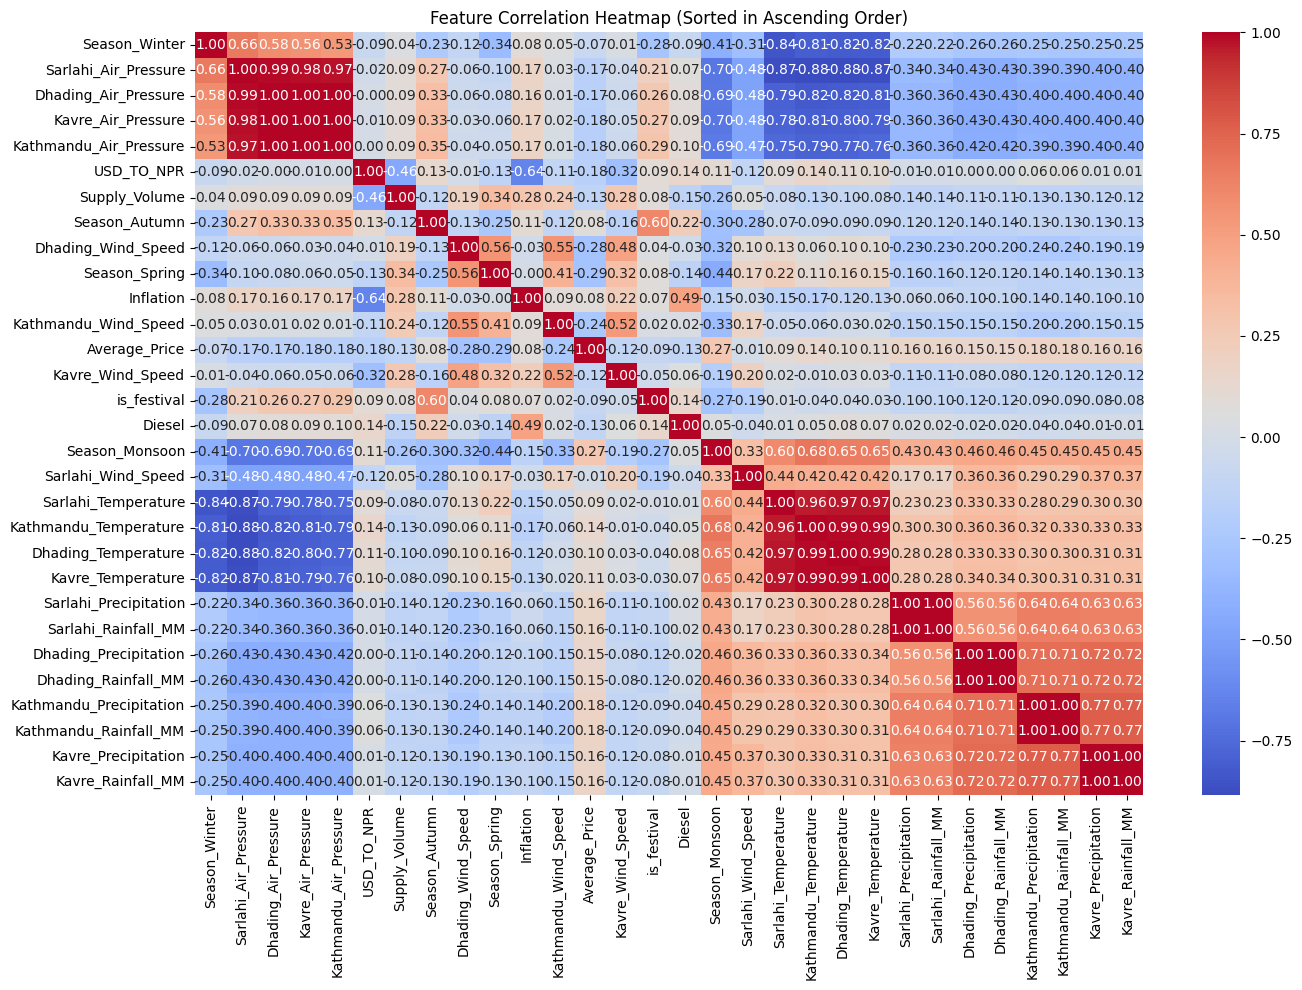

 Saved: artifacts/eda_images/correlation_heatmap_default.png


In [19]:
# Compute correlation matrix
corr = df[num_cols].corr()

# Sort features by mean correlation value (ascending order)
sorted_cols = corr.mean().sort_values(ascending=True).index
corr_sorted = corr.loc[sorted_cols, sorted_cols]

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_sorted, annot=True, cmap='coolwarm', fmt=".2f", ax=ax)
ax.set_title("Feature Correlation Heatmap (Sorted in Ascending Order)")
plt.tight_layout()
plt.show()

# Save figure
save_fig(fig, "correlation_heatmap_default")

In [20]:
# --- Pairplot (relationships) ---
# fig = sns.pairplot(df[num_cols], diag_kind="kde")
# fig.fig.suptitle("Pairwise Relationships", y=1.02)
# fig.savefig("artifacts/eda_images/pairplot.png", dpi=150)
# plt.show()
# plt.close()
# print("📸 Saved: artifacts/eda_images/pairplot.png")

In [21]:
# --- Violinplots to visualize distributions + outliers ---
for col in num_cols:
    fig, ax = plt.subplots(figsize=(5,4))
    sns.violinplot(x=df[col], inner="quartile", color='lightblue', ax=ax)
    ax.set_title(f"Violin Plot of {col}")
    # plt.show()
    save_fig(fig, f"violin_{col}")


 Saved: artifacts/eda_images/violin_Average_Price.png
 Saved: artifacts/eda_images/violin_Supply_Volume.png
 Saved: artifacts/eda_images/violin_USD_TO_NPR.png
 Saved: artifacts/eda_images/violin_Diesel.png
 Saved: artifacts/eda_images/violin_is_festival.png
 Saved: artifacts/eda_images/violin_Season_Autumn.png
 Saved: artifacts/eda_images/violin_Season_Monsoon.png
 Saved: artifacts/eda_images/violin_Season_Spring.png
 Saved: artifacts/eda_images/violin_Season_Winter.png
 Saved: artifacts/eda_images/violin_Inflation.png
 Saved: artifacts/eda_images/violin_Dhading_Wind_Speed.png
 Saved: artifacts/eda_images/violin_Dhading_Temperature.png
 Saved: artifacts/eda_images/violin_Dhading_Precipitation.png
 Saved: artifacts/eda_images/violin_Dhading_Rainfall_MM.png
 Saved: artifacts/eda_images/violin_Dhading_Air_Pressure.png
 Saved: artifacts/eda_images/violin_Kathmandu_Wind_Speed.png
 Saved: artifacts/eda_images/violin_Kathmandu_Temperature.png
 Saved: artifacts/eda_images/violin_Kathmandu_Prec

In [22]:
if "imported_tomato_price" in df.columns:
    season_cols = [c for c in df.columns if c.startswith("Season_")]
    for season in season_cols:
        fig, ax = plt.subplots(figsize=(5,4))
        sns.boxplot(x=df[season], y=df["imported_tomato_price"], ax=ax)
        ax.set_title(f"Tomato Price vs {season}")
        plt.show()
        save_fig(fig, f"price_vs_{season}")

In [23]:
if not np.issubdtype(df['Date'].dtype, np.datetime64):
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# Drop rows where date parsing failed
df = df.dropna(subset=['Date']).reset_index(drop=True)

# --- Temporal Decomposition ---
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['day_of_week'] = df['Date'].dt.dayofweek  # 0 = Monday, 6 = Sunday
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)


# Monthly (annual) pattern
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

col_categories["temporal_cols"].extend(['Date', 'day', 'month', 'day_of_week', 'is_weekend', 'month_sin', 'month_cos'])

print("\n Temporal & Cyclical features extracted:")
print(df[['Date', 'day', 'month', 'day_of_week', 'is_weekend',
          'month_sin', 'month_cos']].head())


 Temporal & Cyclical features extracted:
        Date  day  month  day_of_week  is_weekend  month_sin  month_cos
0 2022-01-01    1      1            5           1        0.5   0.866025
1 2022-01-02    2      1            6           1        0.5   0.866025
2 2022-01-03    3      1            0           0        0.5   0.866025
3 2022-01-04    4      1            1           0        0.5   0.866025
4 2022-01-05    5      1            2           0        0.5   0.866025


In [24]:
def create_lag_features(df, lag_config):
    """
    Create lag features for multiple columns, each with custom lag ranges.
    
    Parameters:
        df (pd.DataFrame): The input dataframe.
        lag_config (dict): Dictionary like {'col_name': [1, 3, 7], ...}
    """
    df_lagged = df.copy()
    for col, lags in lag_config.items():
        for lag in lags:
            col_name = f"{col}_lag{lag}"
            df_lagged[col_name] = df_lagged[col].shift(lag)
            
            # Add to respective category
            for col_category in col_categories.keys():
                if col in col_categories[col_category]:
                    col_categories[col_category].append(col_name)
    return df_lagged


def create_rolling_features(df, roll_config, use_std=False):
    """
    Create rolling mean and (optionally) std features with custom windows per column.
    
    Parameters:
        df (pd.DataFrame): The input dataframe.
        roll_config (dict): Dictionary like {'col_name': [7, 30], ...}
        use_std (bool): Whether to include rolling std features.
    """
    df_roll = df.copy()
    for col, windows in roll_config.items():
        for w in windows:
            mean_col = f"{col}_rollmean_{w}"
            df_roll[mean_col] = df_roll[col].rolling(window=w).mean()
            
            # Add to respective category
            for col_category in col_categories.keys():
                if col in col_categories[col_category]:
                    col_categories[col_category].append(mean_col)
            
            if use_std:
                std_col = f"{col}_rollstd_{w}"
                df_roll[std_col] = df_roll[col].rolling(window=w).std()
                
                for col_category in col_categories.keys():
                    if col in col_categories[col_category]:
                        col_categories[col_category].append(std_col)
    return df_roll


def combine_lag_and_roll(df, lag_config, roll_config, use_std=False):
    """
    Combine lag and rolling features per-column with custom configurations.
    """
    df_combo = create_lag_features(df, lag_config)
    df_combo = create_rolling_features(df_combo, roll_config, use_std=use_std)
    df_combo = df_combo.dropna().reset_index(drop=True)
    return df_combo


In [25]:
# Create lagged features using per-column lag configuration
df_with_lags = create_lag_features(df, lag_config=custom_lag_config)

# Create rolling features using per-column rolling configuration
df_with_rolls = create_rolling_features(df, roll_config=custom_roll_config, use_std=standard_deviation_lag)

# Combine both lag and rolling features
df_with_lag_roll = combine_lag_and_roll(
    df,
    lag_config=custom_lag_config,
    roll_config=custom_roll_config,
    use_std=standard_deviation_lag
)

print("\n✅ Lagged and Rolling Features Created")
display(df_with_lag_roll.head())



✅ Lagged and Rolling Features Created


,Date,Average_Price,Supply_Volume,USD_TO_NPR,Diesel,is_festival,Season_Autumn,Season_Monsoon,Season_Spring,Season_Winter,...,Average_Price_lag1,Average_Price_lag3,Average_Price_lag7,Supply_Volume_lag1,Supply_Volume_lag7,Supply_Volume_lag30,Average_Price_rollmean_7,Average_Price_rollmean_30,Supply_Volume_rollmean_30,Supply_Volume_rollmean_90
0,2022-03-31,55.00,107060.0,121.76,138.0,0,False,False,True,False,...,55.00,60.00,67.5,76280.0,159257.5,86640.0,60.000000,59.451000,76907.966667,45691.488889
1,2022-04-01,56.67,110200.0,121.57,138.0,0,False,False,True,False,...,55.00,55.00,65.0,107060.0,185920.0,62800.0,58.810000,59.451000,78487.966667,46827.044444
2,2022-04-02,56.67,106650.0,121.57,138.0,0,False,False,True,False,...,56.67,55.00,65.0,110200.0,85960.0,23750.0,57.620000,59.451000,81251.300000,47923.155556
3,2022-04-03,55.00,141475.0,121.57,138.0,0,False,False,True,False,...,56.67,55.00,65.0,106650.0,59825.0,35600.0,56.191429,59.256333,84780.466667,49246.488889
4,2022-04-04,55.00,105025.0,121.57,138.0,0,False,False,True,False,...,55.00,56.67,60.0,141475.0,52662.5,47450.0,55.477143,58.923000,86699.633333,50324.544444


In [26]:
# --------- Save cleaned datasets ---------
no_lag_path = "artifacts/data/clean_data.csv"
lagged_path = "artifacts/data/clean_data_with_lags.csv"
roll_path = "artifacts/data/clean_data_with_lag_roll.csv"

df.to_csv(no_lag_path, index=False)
df_with_lags.dropna().to_csv(lagged_path, index=False)
df_with_lag_roll.to_csv(roll_path, index=False)

print(f"\n Saved cleaned data (no lags) → {no_lag_path}")
print(f" Saved lag-only data → {lagged_path}")
print(f" Saved lag + rolling data → {roll_path}")


 Saved cleaned data (no lags) → artifacts/data/clean_data.csv
 Saved lag-only data → artifacts/data/clean_data_with_lags.csv
 Saved lag + rolling data → artifacts/data/clean_data_with_lag_roll.csv


In [27]:
df.columns

Index(['Date', 'Average_Price', 'Supply_Volume', 'USD_TO_NPR', 'Diesel',
       'is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring',
       'Season_Winter', 'Inflation', 'Dhading_Wind_Speed',
       'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM',
       'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed', 'Kathmandu_Temperature',
       'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM',
       'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed', 'Kavre_Temperature',
       'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure',
       'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation',
       'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure', 'day', 'month',
       'day_of_week', 'is_weekend', 'month_sin', 'month_cos'],
      dtype='object')

✅ Saved Climate correlation heatmap → artifacts/eda/correlations\corr_climate.png
✅ Saved Economic correlation heatmap → artifacts/eda/correlations\corr_economic.png
✅ Saved Market correlation heatmap → artifacts/eda/correlations\corr_market.png
✅ Saved Temporal correlation heatmap → artifacts/eda/correlations\corr_temporal.png

📊 All correlation heatmaps generated and saved.


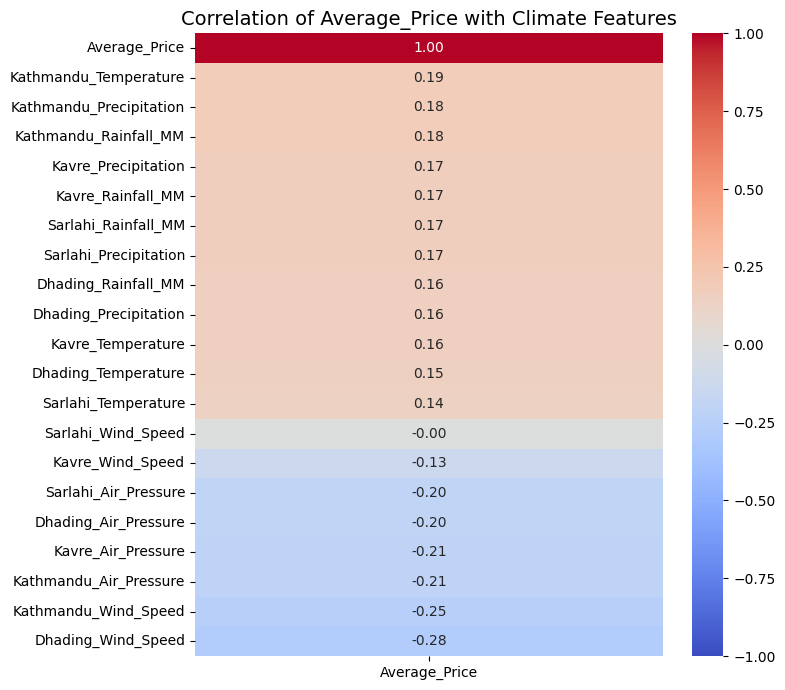

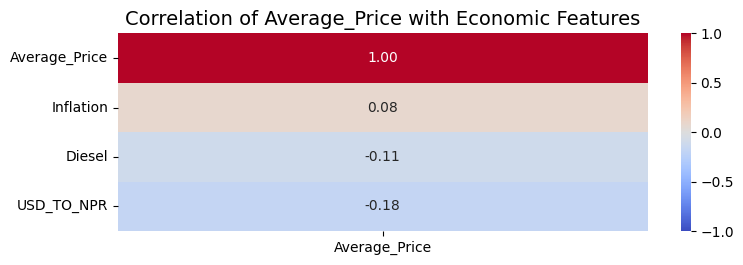

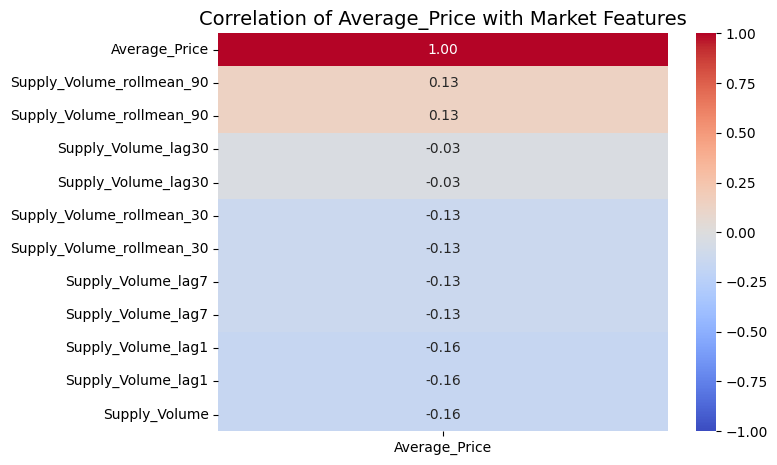

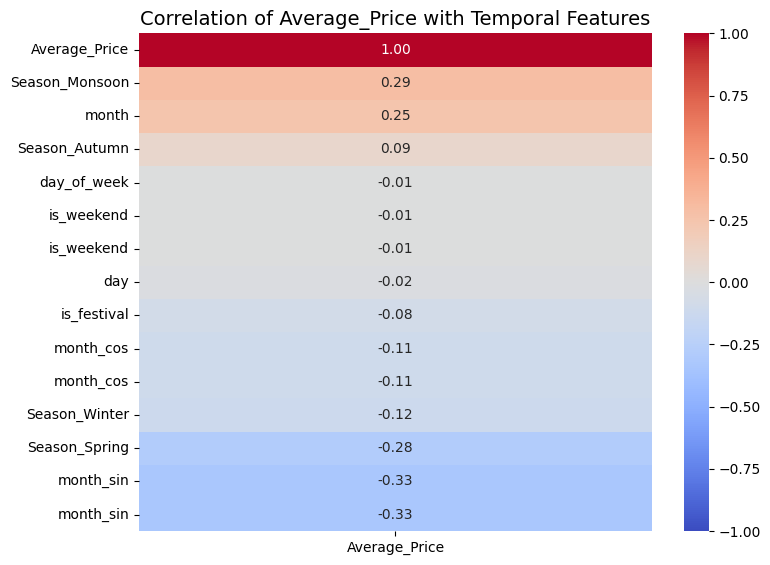

In [28]:


# ============================================================
# ✅ Helper Function: Correlation Heatmap & Save Artifact
# ============================================================

def plot_and_save_corr(df, cols, title, save_dir="artifacts/eda/correlations"):
    os.makedirs(save_dir, exist_ok=True)
    
    subset = df[['Average_Price'] + cols].copy()
    corr = subset.corr(numeric_only=True)
    
    plt.figure(figsize=(8, len(cols) * 0.25 + 2))
    sns.heatmap(
        corr[['Average_Price']].sort_values(by='Average_Price', ascending=False),
        annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f"
    )
    plt.title(f'Correlation of Average_Price with {title} Features', fontsize=14)
    plt.tight_layout()

    # Save plot
    save_path = os.path.join(save_dir, f"corr_{title.lower()}.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.plot()
    # plt.close()

    print(f"✅ Saved {title} correlation heatmap → {save_path}")

# ============================================================
# ✅ Generate and Save Correlation Plots
# ============================================================
for category_name, columns in col_categories.items():
    plot_and_save_corr(df_with_lag_roll, columns, category_name.replace('_cols', '').capitalize())


print("\n📊 All correlation heatmaps generated and saved.")


In [29]:
print(col_categories)

{'climate_cols': ['Dhading_Wind_Speed', 'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM', 'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed', 'Kathmandu_Temperature', 'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM', 'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed', 'Kavre_Temperature', 'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure', 'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation', 'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure'], 'economic_cols': ['USD_TO_NPR', 'Diesel', 'Inflation'], 'market_cols': ['Supply_Volume', 'Supply_Volume_lag1', 'Supply_Volume_lag7', 'Supply_Volume_lag30', 'Supply_Volume_rollmean_30', 'Supply_Volume_rollmean_90', 'Supply_Volume_lag1', 'Supply_Volume_lag7', 'Supply_Volume_lag30', 'Supply_Volume_rollmean_30', 'Supply_Volume_rollmean_90'], 'temporal_cols': ['is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter', 'is_weekend', 'month_sin', 'month_cos', 'Date', 'day', 'month', 'day_of

In [30]:
print(col_categories_no_lag)

{'climate_cols': ['Dhading_Wind_Speed', 'Dhading_Temperature', 'Dhading_Precipitation', 'Dhading_Rainfall_MM', 'Dhading_Air_Pressure', 'Kathmandu_Wind_Speed', 'Kathmandu_Temperature', 'Kathmandu_Precipitation', 'Kathmandu_Rainfall_MM', 'Kathmandu_Air_Pressure', 'Kavre_Wind_Speed', 'Kavre_Temperature', 'Kavre_Precipitation', 'Kavre_Rainfall_MM', 'Kavre_Air_Pressure', 'Sarlahi_Wind_Speed', 'Sarlahi_Temperature', 'Sarlahi_Precipitation', 'Sarlahi_Rainfall_MM', 'Sarlahi_Air_Pressure'], 'economic_cols': ['USD_TO_NPR', 'Diesel', 'Inflation'], 'market_cols': ['Supply_Volume'], 'temporal_cols': ['is_festival', 'Season_Autumn', 'Season_Monsoon', 'Season_Spring', 'Season_Winter', 'is_weekend', 'month_sin', 'month_cos']}


In [31]:
import joblib
joblib.dump(col_categories, "col_categories_lag.joblib")
joblib.dump(col_categories_no_lag,"col_categories.joblib")

['col_categories.joblib']